In [0]:
ls /databricks-datasets/learning-spark-v2/people/people-10m.parquet/

part-00000-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00001-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00002-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00003-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00004-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00005-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00006-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
part-00007-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*
_SUCCESS*



part-00000-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00001-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00002-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00003-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00004-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00005-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00006-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
part-00007-04bbf354-608c-43f2-9a81-7df139d1af69.snappy.parquet*<br>
_SUCCESS*

In [0]:
%sql
select 
count(*)
from parquet.`/databricks-datasets/learning-spark-v2/people/people-10m.parquet/`

count(*)
10000000


10000000

In [0]:
%sql
select 
*
from parquet.`/databricks-datasets/learning-spark-v2/people/people-10m.parquet/` limit 10

id,firstName,middleName,lastName,gender,birthDate,ssn,salary
1,Pennie,Carry,Hirschmann,F,1955-07-02T04:00:00.000Z,981-43-9345,56172
2,An,Amira,Cowper,F,1992-02-08T05:00:00.000Z,978-97-8086,40203
3,Quyen,Marlen,Dome,F,1970-10-11T04:00:00.000Z,957-57-8246,53417
4,Coralie,Antonina,Marshal,F,1990-04-11T04:00:00.000Z,963-39-4885,94727
5,Terrie,Wava,Bonar,F,1980-01-16T05:00:00.000Z,964-49-8051,79908
6,Chassidy,Concepcion,Bourthouloume,F,1990-11-24T05:00:00.000Z,954-59-9172,64652
7,Geri,Tambra,Mosby,F,1970-12-19T05:00:00.000Z,968-16-4020,38195
8,Patria,Nancy,Arstall,F,1985-01-02T05:00:00.000Z,984-76-3770,102053
9,Terese,Alfredia,Tocque,F,1967-11-17T05:00:00.000Z,967-48-7309,91294
10,Wava,Lyndsey,Jeandon,F,1963-12-30T05:00:00.000Z,997-82-2946,56521


id	firstName	middleName	lastName	gender	birthDate	ssn	salary<br>
1	Pennie	Carry	Hirschmann	F	1955-07-02T04:00:00.000+00:00	981-43-9345	56172 <br>
2	An	Amira	Cowper	F	1992-02-08T05:00:00.000+00:00	978-97-8086	40203 <br>
3	Quyen	Marlen	Dome	F	1970-10-11T04:00:00.000+00:00	957-57-8246	53417<br>
4	Coralie	Antonina	Marshal	F	1990-04-11T04:00:00.000+00:00	963-39-4885	94727<br>
5	Terrie	Wava	Bonar	F	1980-01-16T05:00:00.000+00:00	964-49-8051	79908<br>



1.SSN Validation:<br>
a.Identify unique records based on SSN.Take last records based on birthdays<br>
b.Ensure we have correct ssn format (XXX-XX-XXXX)<br>
c.Mask the SSN <br>
2.Create a report based age group from currentdays
as example <br>
Age Group | Person Count<br>
0-20 | 100 <br>
Compute average salary based on group
visualize the result based with bar chart
3. Calculate bonus for the person who is having more than 60 years of age 
4.generate relation based 

In [0]:
from pyspark.sql import SparkSession
spark=SparkSession.builder.appName("People_dataset_analysis").getOrCreate()
df = spark.read.parquet("/databricks-datasets/learning-spark-v2/people/people-10m.parquet/")
display(df.show(5))

+---+---------+----------+----------+------+-------------------+-----------+------+
| id|firstName|middleName|  lastName|gender|          birthDate|        ssn|salary|
+---+---------+----------+----------+------+-------------------+-----------+------+
|  1|   Pennie|     Carry|Hirschmann|     F|1955-07-02 04:00:00|981-43-9345| 56172|
|  2|       An|     Amira|    Cowper|     F|1992-02-08 05:00:00|978-97-8086| 40203|
|  3|    Quyen|    Marlen|      Dome|     F|1970-10-11 04:00:00|957-57-8246| 53417|
|  4|  Coralie|  Antonina|   Marshal|     F|1990-04-11 04:00:00|963-39-4885| 94727|
|  5|   Terrie|      Wava|     Bonar|     F|1980-01-16 05:00:00|964-49-8051| 79908|
+---+---------+----------+----------+------+-------------------+-----------+------+
only showing top 5 rows


In [0]:
#checking if any null values
from pyspark.sql.functions import col
df.na.drop().count()
df.filter(col("firstName").isNull()|col("birthDate").isNull()|col("ssn").isNull()|col("ssn").isNull()|col("gender").isNull()).show()

+---+---------+----------+--------+------+---------+---+------+
| id|firstName|middleName|lastName|gender|birthDate|ssn|salary|
+---+---------+----------+--------+------+---------+---+------+
+---+---------+----------+--------+------+---------+---+------+



In [0]:
%python
from pyspark.sql.functions import count, col
df.groupBy('ssn').agg(count("id").alias("SSN_Count")).where(col("SSN_Count") > 1).count()



569911

In [0]:
df.groupBy('ssn').agg(count("id").alias("SSN_Count")).where(col("SSN_Count") > 1).show(10)

+-----------+---------+
|        ssn|SSN_Count|
+-----------+---------+
|906-78-8127|        2|
|933-43-5600|        2|
|993-48-8925|        2|
|940-56-1575|        2|
|942-41-3313|        2|
|950-12-2859|        2|
|993-82-3770|        2|
|973-62-7527|        2|
|914-78-7377|        2|
|934-45-4535|        2|
+-----------+---------+
only showing top 10 rows


In [0]:
df.groupBy('ssn').agg(count("id").alias("SSN_Count")).where(col("SSN_Count") > 2).show(10)

+-----------+---------+
|        ssn|SSN_Count|
+-----------+---------+
|901-57-1338|        3|
|915-90-7776|        3|
|972-82-2631|        3|
|963-24-6919|        3|
|937-90-1011|        3|
|938-44-7253|        3|
|944-92-2756|        4|
|968-93-1628|        3|
|968-19-4998|        3|
|990-67-3625|        3|
+-----------+---------+
only showing top 10 rows


In [0]:
df.filter(col("ssn")=='944-92-2756').show()

+-------+---------+----------+---------+------+-------------------+-----------+------+
|     id|firstName|middleName| lastName|gender|          birthDate|        ssn|salary|
+-------+---------+----------+---------+------+-------------------+-----------+------+
|1052379| Kenyatta|    Shella|   Gurton|     F|1964-03-07 05:00:00|944-92-2756|100802|
|3384844|   Janeth|      Etha|    Asser|     F|1990-01-08 05:00:00|944-92-2756| 26353|
|6908801|  Quinton|   Arnulfo|Andreotti|     M|1992-11-29 05:00:00|944-92-2756| 81859|
|9604376|    Chuck|    Johnny|   Chotty|     M|1971-02-16 05:00:00|944-92-2756| 51837|
+-------+---------+----------+---------+------+-------------------+-----------+------+



In [0]:
df.filter(col("ssn")=='972-82-2631').show()

+-------+---------+----------+--------+------+-------------------+-----------+------+
|     id|firstName|middleName|lastName|gender|          birthDate|        ssn|salary|
+-------+---------+----------+--------+------+-------------------+-----------+------+
| 305288|  Marylee|     Maple|   Prout|     F|1982-02-11 05:00:00|972-82-2631| 53375|
|2961351|   Benita|      Faye|   Povah|     F|1969-02-28 05:00:00|972-82-2631| 41263|
|9512113|    Brant|     Vince|O'Sherin|     M|1977-09-12 04:00:00|972-82-2631| 76685|
+-------+---------+----------+--------+------+-------------------+-----------+------+



In [0]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number,desc 
window_spec =Window.partitionBy('ssn').orderBy(desc('birthDate'))
df_distinct_ssn=df.withColumn('latest_ssn',row_number().over(window_spec)).where("latest_ssn=1")

In [0]:
df_distinct_ssn.count()

9405965

In [0]:
from pyspark.sql.functions import date_diff,current_date,round
df_new =df_distinct_ssn.withColumn('Age',round(date_diff(current_date(),col('birthDate'))/365))

In [0]:
display(df_new.show(5))

+-------+---------+----------+----------+------+-------------------+-----------+------+----------+----+
|     id|firstName|middleName|  lastName|gender|          birthDate|        ssn|salary|latest_ssn| Age|
+-------+---------+----------+----------+------+-------------------+-----------+------+----------+----+
|9065956|    Ralph|      Kris|  Gonthier|     M|1956-09-24 04:00:00|666-10-1021| 77336|         1|69.0|
|6271319|  Arnulfo|    Fabian|   Wickins|     M|1970-11-04 05:00:00|666-10-1045| 45594|         1|55.0|
|8404669|    Mitch|    Dorian|  Foxcroft|     M|1986-11-14 05:00:00|666-10-1102| 68288|         1|39.0|
|4998546|   Gudrun| Celestine|Manntschke|     F|1972-02-01 05:00:00|666-10-1153| 66132|         1|54.0|
|9029190|   Junior|  Stanford|   Ilewicz|     M|1976-10-23 04:00:00|666-10-1157| 81444|         1|49.0|
+-------+---------+----------+----------+------+-------------------+-----------+------+----------+----+
only showing top 5 rows


In [0]:
#check any null data is there
df_new.filter(col("gender").isNull()).show()

+---+---------+----------+--------+------+---------+---+------+----------+---+
| id|firstName|middleName|lastName|gender|birthDate|ssn|salary|latest_ssn|Age|
+---+---------+----------+--------+------+---------+---+------+----------+---+
+---+---------+----------+--------+------+---------+---+------+----------+---+



In [0]:
df_new.filter(col("salary").isNull()).show()

+---+---------+----------+--------+------+---------+---+------+----------+---+
| id|firstName|middleName|lastName|gender|birthDate|ssn|salary|latest_ssn|Age|
+---+---------+----------+--------+------+---------+---+------+----------+---+
+---+---------+----------+--------+------+---------+---+------+----------+---+



In [0]:
df_new.filter(col("birthDate").isNull()).show()

+---+---------+----------+--------+------+---------+---+------+----------+---+
| id|firstName|middleName|lastName|gender|birthDate|ssn|salary|latest_ssn|Age|
+---+---------+----------+--------+------+---------+---+------+----------+---+
+---+---------+----------+--------+------+---------+---+------+----------+---+



In [0]:
df_female=df_new.filter(col("gender")=='Female')
df_male=df_new.filter(col("gender")=='Male')

In [0]:
df_male.corr("Age","salary")

nan

In [0]:
df_female.corr("Age","salary")

nan

In [0]:
df_new.describe().show()

+-------+-----------------+---------+----------+--------+-------+-----------+------------------+--------------------+------------------+
|summary|               id|firstName|middleName|lastName| gender|        ssn|            salary|          latest_ssn|               Age|
+-------+-----------------+---------+----------+--------+-------+-----------+------------------+--------------------+------------------+
|  count|          9405965|  9405965|   9405965| 9405965|9405965|    9405965|           9405965|             9405965|           9405965|
|   mean|4999529.971919096|      NaN|       NaN|    NULL|   NULL|       NULL| 72632.33905739602|                 1.0| 49.45878726956777|
| stddev|2886914.672431827|      NaN|       NaN|    NULL|   NULL|       NULL|20004.428747871483|4.759743015462578...|13.890150196756158|
|    min|                1|    Aaron|     Aaron|A'Barrow|      F|666-10-1005|            -26884|                   1|              26.0|
|    max|          9999999|    Zulma|    

In [0]:
df_new.describe("salary").show()

+-------+------------------+
|summary|            salary|
+-------+------------------+
|  count|           9405965|
|   mean| 72632.33905739602|
| stddev|20004.428747871483|
|    min|            -26884|
|    max|            180841|
+-------+------------------+



In [0]:
df_new.filter(col("salary")> 0).describe().show()

+-------+------------------+---------+----------+--------+-------+-----------+-----------------+--------------------+------------------+
|summary|                id|firstName|middleName|lastName| gender|        ssn|           salary|          latest_ssn|               Age|
+-------+------------------+---------+----------+--------+-------+-----------+-----------------+--------------------+------------------+
|  count|           9404611|  9404611|   9404611| 9404611|9404611|    9404611|          9404611|             9404611|           9404611|
|   mean| 4999507.414065398|      NaN|       NaN|    NULL|   NULL|       NULL|72643.48094089165|                 1.0|49.458785376662576|
| stddev|2886918.1702690055|      NaN|       NaN|    NULL|   NULL|       NULL|19984.23000405512|4.759755447699053...|13.890136272250913|
|    min|                 1|    Aaron|     Aaron|A'Barrow|      F|666-10-1005|                3|                   1|              26.0|
|    max|           9999999|    Zulma|   

In [0]:
from pyspark.sql.functions import abs
df_new.select(abs(col("salary"))).show(10)

+-----------+
|abs(salary)|
+-----------+
|      77336|
|      45594|
|      68288|
|      66132|
|      81444|
|      74912|
|     104216|
|      72018|
|      82185|
|      62722|
+-----------+
only showing top 10 rows


In [0]:
from pyspark.sql.functions import min,max
df_new.select(min(col("salary"))).display()

min(salary)
-26884


In [0]:
def Salary_status(salary):
    if salary < 45000:
        return "Low"
    elif salary >= 45000 and salary < 90000:
        return "Medium"
    else:
        return "High"


In [0]:
print(Salary_status(90000))

High


In [0]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
salary_status_udf = udf(Salary_status,StringType())

In [0]:
df_new.withColumn("Salary_grade",salary_status_udf(df_new["salary"])).show(10)

+-------+---------+----------+-----------+------+-------------------+-----------+------+----------+----+------------+
|     id|firstName|middleName|   lastName|gender|          birthDate|        ssn|salary|latest_ssn| Age|Salary_grade|
+-------+---------+----------+-----------+------+-------------------+-----------+------+----------+----+------------+
|9065956|    Ralph|      Kris|   Gonthier|     M|1956-09-24 04:00:00|666-10-1021| 77336|         1|69.0|      Medium|
|6271319|  Arnulfo|    Fabian|    Wickins|     M|1970-11-04 05:00:00|666-10-1045| 45594|         1|55.0|      Medium|
|8404669|    Mitch|    Dorian|   Foxcroft|     M|1986-11-14 05:00:00|666-10-1102| 68288|         1|39.0|      Medium|
|4998546|   Gudrun| Celestine| Manntschke|     F|1972-02-01 05:00:00|666-10-1153| 66132|         1|54.0|      Medium|
|9029190|   Junior|  Stanford|    Ilewicz|     M|1976-10-23 04:00:00|666-10-1157| 81444|         1|49.0|      Medium|
|7009597|      Von|   Malcolm|   Glanvill|     M|1959-04

In [0]:
def age_bining(age):
    if age < 20:
        return "Below 20"
    elif age >= 20 and age < 40:
        return "Between 20 and 40"
    elif age >= 40 and age < 60:
        return "Between 40 and 60"
    elif age >= 60 and age < 80:
        return "Between 60 and 80"
    else:
        return "Above 80"

In [0]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
age_bining_udf = udf(age_bining,StringType())

In [0]:
df_new =df_new.withColumn("age_group",age_bining_udf(df_new["age"]))
df_new.show()

+-------+---------+----------+-----------+------+-------------------+-----------+------+----------+----+-----------------+
|     id|firstName|middleName|   lastName|gender|          birthDate|        ssn|salary|latest_ssn| Age|        age_group|
+-------+---------+----------+-----------+------+-------------------+-----------+------+----------+----+-----------------+
|9065956|    Ralph|      Kris|   Gonthier|     M|1956-09-24 04:00:00|666-10-1021| 77336|         1|69.0|Between 60 and 80|
|6271319|  Arnulfo|    Fabian|    Wickins|     M|1970-11-04 05:00:00|666-10-1045| 45594|         1|55.0|Between 40 and 60|
|8404669|    Mitch|    Dorian|   Foxcroft|     M|1986-11-14 05:00:00|666-10-1102| 68288|         1|39.0|Between 20 and 40|
|4998546|   Gudrun| Celestine| Manntschke|     F|1972-02-01 05:00:00|666-10-1153| 66132|         1|54.0|Between 40 and 60|
|9029190|   Junior|  Stanford|    Ilewicz|     M|1976-10-23 04:00:00|666-10-1157| 81444|         1|49.0|Between 40 and 60|
|7009597|      V

In [0]:
from pyspark.sql.functions import avg,mean,mode
df_new.groupby("age_group","gender").agg(count("id").alias("Person_count"),
                                         max("salary").alias("Max_Salary"),
                                         min("salary").alias("Min_Salary"),
                                         mode("salary").alias("mode_Salary"),
                                         avg("salary").alias("Avg_Salary")).show()

+-----------------+------+------------+----------+----------+-----------+-----------------+
|        age_group|gender|Person_count|Max_Salary|Min_Salary|mode_Salary|       Avg_Salary|
+-----------------+------+------------+----------+----------+-----------+-----------------+
|Between 40 and 60|     M|     1882284|    170371|    -24221|      75692|72612.77141122169|
|Between 20 and 40|     M|     1338381|    170562|    -25644|      69233|72642.19254756306|
|Between 40 and 60|     F|     2029581|    168966|    -26884|      74193|72615.06575051698|
|Between 20 and 40|     F|     1439814|    173969|    -22033|      72454| 72651.7928565773|
|Between 60 and 80|     F|     1410281|    180841|    -20925|      79210|72646.80707390938|
|Between 60 and 80|     M|     1305624|    164624|    -24468|      72379|72640.21873602201|
+-----------------+------+------------+----------+----------+-----------+-----------------+



In [0]:
q1 = df_new.approxQuantile(
    "salary",
    [0.25],
    0.01
)[0]
q3 = df_new.approxQuantile(
    "salary",
    [0.75],
    0.01
)[0]
display(q1)
print("---------------------")
display(q3)

58910.0

---------------------


86071.0

In [0]:
iqr= q3-q1
lower_bound=q1-iqr*1.5
upper_bound=q3+iqr*1.5
print(iqr)
print(lower_bound)
print(upper_bound)

27161.0
18168.5
126812.5


In [0]:
df_new.filter(df["salary"] > upper_bound).count()

31591

In [0]:
df_new.filter(df["salary"] < lower_bound).count()

30887

In [0]:
df_new.count()

9405965

In [0]:
((31591+30887)/9405965)

0.006642380659507025

In [0]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df_pd=df_new.toPandas()

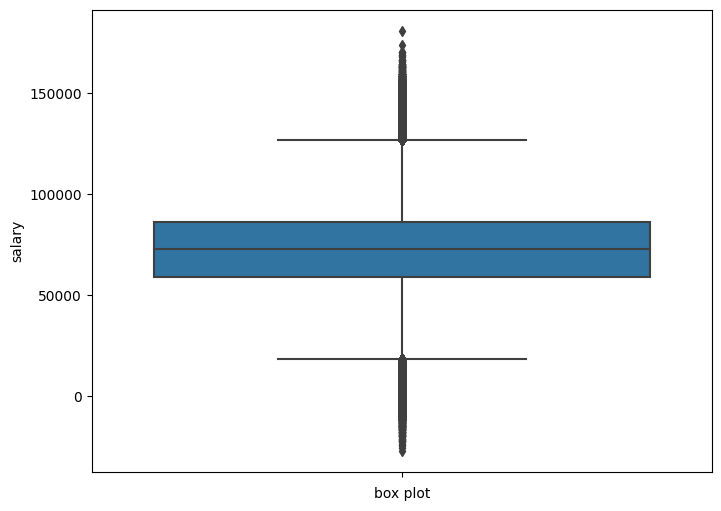

In [0]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df_pd["salary"])
plt.xlabel("box plot")
plt.show()

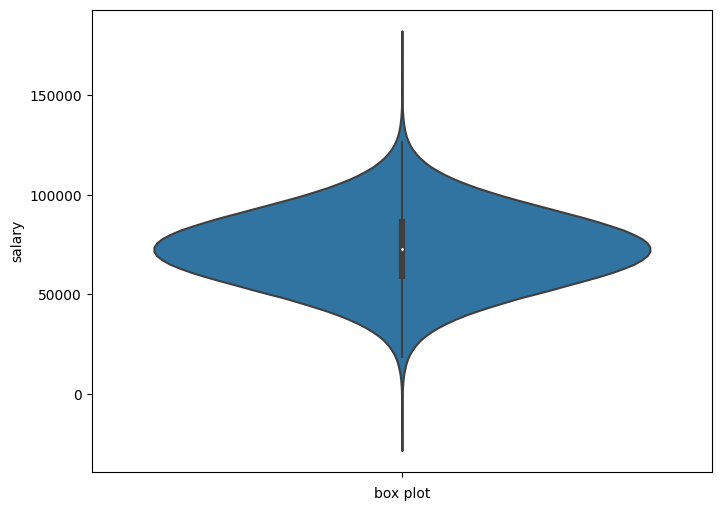

In [0]:
plt.figure(figsize=(8,6))
sns.violinplot(y=df_pd["salary"])
plt.xlabel("box plot")
plt.show()

In [0]:
df_new.filter(df["salary"] < 0).count()

1354

In [0]:
from pyspark.sql.functions import col,when
df_new=df_new.select(col("id"),
                     col("firstName"),
                     col("middleName"),
                     col("lastName"),
                     col("gender"),
                     col("age"),
                     col("ssn"),
                     when(df_new["salary"]<0,lower_bound).otherwise(df_new["salary"]).alias("salary")
                     )
df_new.show()

+-------+---------+----------+-----------+------+----+-----------+--------+
|     id|firstName|middleName|   lastName|gender| age|        ssn|  salary|
+-------+---------+----------+-----------+------+----+-----------+--------+
|9065956|    Ralph|      Kris|   Gonthier|     M|69.0|666-10-1021| 77336.0|
|6271319|  Arnulfo|    Fabian|    Wickins|     M|55.0|666-10-1045| 45594.0|
|8404669|    Mitch|    Dorian|   Foxcroft|     M|39.0|666-10-1102| 68288.0|
|4998546|   Gudrun| Celestine| Manntschke|     F|54.0|666-10-1153| 66132.0|
|9029190|   Junior|  Stanford|    Ilewicz|     M|49.0|666-10-1157| 81444.0|
|7009597|      Von|   Malcolm|   Glanvill|     M|67.0|666-10-1189| 74912.0|
|6518891|    Jerry|    Tyrell|    Wardall|     M|41.0|666-10-1224|104216.0|
|1124776|    Carli|    Marcie|Mylechreest|     F|31.0|666-10-1262| 72018.0|
|6224307|   Fermin|       Ned|    Sockell|     M|49.0|666-10-1333| 82185.0|
|5527540|  Dominic|    Rodger|  Gouinlock|     M|67.0|666-10-1391| 62722.0|
|9242248|   

In [0]:
df_new.filter(df["salary"] < 0).count()

0

In [0]:
df_new.printSchema()

root
 |-- id: integer (nullable = true)
 |-- firstName: string (nullable = true)
 |-- middleName: string (nullable = true)
 |-- lastName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- ssn: string (nullable = true)
 |-- salary: double (nullable = true)



In [0]:
df_new.filter((df["salary"]>= lower_bound) & (df["salary"] <= upper_bound)).count()

9344841

In [0]:
df_people =df_new.filter((df["salary"]>= lower_bound) & (df["salary"] <= upper_bound))

In [0]:
df_people.show(5)

+-------+---------+----------+----------+------+----+-----------+-------+
|     id|firstName|middleName|  lastName|gender| age|        ssn| salary|
+-------+---------+----------+----------+------+----+-----------+-------+
|9065956|    Ralph|      Kris|  Gonthier|     M|69.0|666-10-1021|77336.0|
|6271319|  Arnulfo|    Fabian|   Wickins|     M|55.0|666-10-1045|45594.0|
|8404669|    Mitch|    Dorian|  Foxcroft|     M|39.0|666-10-1102|68288.0|
|4998546|   Gudrun| Celestine|Manntschke|     F|54.0|666-10-1153|66132.0|
|9029190|   Junior|  Stanford|   Ilewicz|     M|49.0|666-10-1157|81444.0|
+-------+---------+----------+----------+------+----+-----------+-------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import expr
df_people.withColumn('SSN_CHECK',expr("length(ssn)")).filter(col('SSN_CHECK') == 11 ).show()

+-------+---------+----------+-----------+------+----+-----------+--------+---------+
|     id|firstName|middleName|   lastName|gender| age|        ssn|  salary|SSN_CHECK|
+-------+---------+----------+-----------+------+----+-----------+--------+---------+
|9065956|    Ralph|      Kris|   Gonthier|     M|69.0|666-10-1021| 77336.0|       11|
|6271319|  Arnulfo|    Fabian|    Wickins|     M|55.0|666-10-1045| 45594.0|       11|
|8404669|    Mitch|    Dorian|   Foxcroft|     M|39.0|666-10-1102| 68288.0|       11|
|4998546|   Gudrun| Celestine| Manntschke|     F|54.0|666-10-1153| 66132.0|       11|
|9029190|   Junior|  Stanford|    Ilewicz|     M|49.0|666-10-1157| 81444.0|       11|
|7009597|      Von|   Malcolm|   Glanvill|     M|67.0|666-10-1189| 74912.0|       11|
|6518891|    Jerry|    Tyrell|    Wardall|     M|41.0|666-10-1224|104216.0|       11|
|1124776|    Carli|    Marcie|Mylechreest|     F|31.0|666-10-1262| 72018.0|       11|
|6224307|   Fermin|       Ned|    Sockell|     M|49.0|

In [0]:
%sh
pwd

/Workspace/Users/sandutta2020@gmail.com/Pyspark


In [0]:
df_people.coalesce(1)
df_people.write.parquet('/Volumes/movie_catalog/movie_schema/temp_storage/people_data')